[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Nishani53/Khanal_MSc_Thesis_MSU/blob/main/Network%20Analysis%20Michigan%20Forestry/Khanal%20Network%20Analysis%20MSU.ipynb)


In [1]:
! pip install geopandas rasterio numpy matplotlib
! pip install --upgrade rasterio
!pip install rasterio geopandas shapely
!pip install geopandas fiona
!pip install matplotlib-scalebar
!pip install gdown
!pip install pydrive
!pip install matplotlib-scalebar

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 64.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 26.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 987.4/987.4 kB 7.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydrive: filename=PyDrive-1.3.1-py3-none-any.whl size=27433 sha256=2c56a5648d4b661e8a82d26c2c7f83249c3a2c3c1f6500bef223d89f8affd1c7
  Stored in directory: /root/.cache/pip/wheels/6c/10/da/a5b513f5b3916fc391c20ee7b4633e5cf3396d570cdd74970f
Successfully built pydrive


In [2]:
# 📁 Step 1: Clean Colab working directory
%cd /content
!rm -rf sample_data/ repo.zip Khanal_MSc_Thesis_MSU-main "Khanal Thesis Data.7z"

# 🛠️ Step 2: Install 7-Zip
!apt-get install -y p7zip-full

# 📥 Step 3: Download your GitHub repo zip
!curl -L -o repo.zip https://github.com/Nishani53/Khanal_MSc_Thesis_MSU/archive/refs/heads/main.zip
!unzip -q repo.zip

# 📂 Step 4: Navigate to the folder containing 'Khanal Thesis Data.7z'
%cd "Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data"

# 📥 Step 5: Download 'Khanal Thesis Data.7z' from GitHub (fresh copy)
!curl -L -o "Khanal Thesis Data.7z" "https://github.com/Nishani53/Khanal_MSc_Thesis_MSU/raw/main/Network%20Analysis%20Michigan%20Forestry/Data/Khanal%20Thesis%20Data.7z"

# 📂 Step 6: Extract the .7z archive
!7z x -y "Khanal Thesis Data.7z"

# 📂 Step 7: Set base path to extracted Data folder inside the archive
base_path = "/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data/Data"

import os

print("📁 Listing all files in extracted Data folder:\n")
for root, dirs, files in os.walk(base_path):
    for file in files:
        print(os.path.join(root, file))


/content
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 30.7M    0 30.7M    0     0  9944k      0 --:--:--  0:00:03 --:--:-- 11.8M
/content/Khanal_MSc_Thesis_MSU-main/Network Analysis Michigan Forestry/Data
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 42.9M  100 42.9M    0     0  11.6M      0  0:00:03  0:00:03 --:--:-- 13.3M

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05

# Files

In [ ]:
import os

folder = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Khanal Manuscript Sept 2025\Hotspots Final"

shp_files = [f for f in os.listdir(folder) if f.endswith('.shp')]

print("Shapefiles found in folder:")
for shp in shp_files:
    print(shp)


Shapefiles found in folder:
Biomass_1985_hotspots.shp
Biomass_1994_hotspots.shp
Biomass_2002_hotspots.shp
Biomass_2018_hotspots.shp
Biomass_2023_hotspots.shp
Hardwood_1985_hotspots.shp
Hardwood_1994_hotspots.shp
Hardwood_2002_hotspots.shp
Hardwood_2018_hotspots.shp
Hardwood_2023_hotspots.shp
Michigan Counties.shp
Pulpwood_1985_hotspots.shp
Pulpwood_1994_hotspots.shp
Pulpwood_2002_hotspots.shp
Pulpwood_2018_hotspots.shp
Pulpwood_2023_hotspots.shp
Softwood_1985_hotspots.shp
Softwood_1994_hotspots.shp
Softwood_2002_hotspots.shp
Softwood_2018_hotspots.shp
Softwood_2023_hotspots.shp


# Softwood

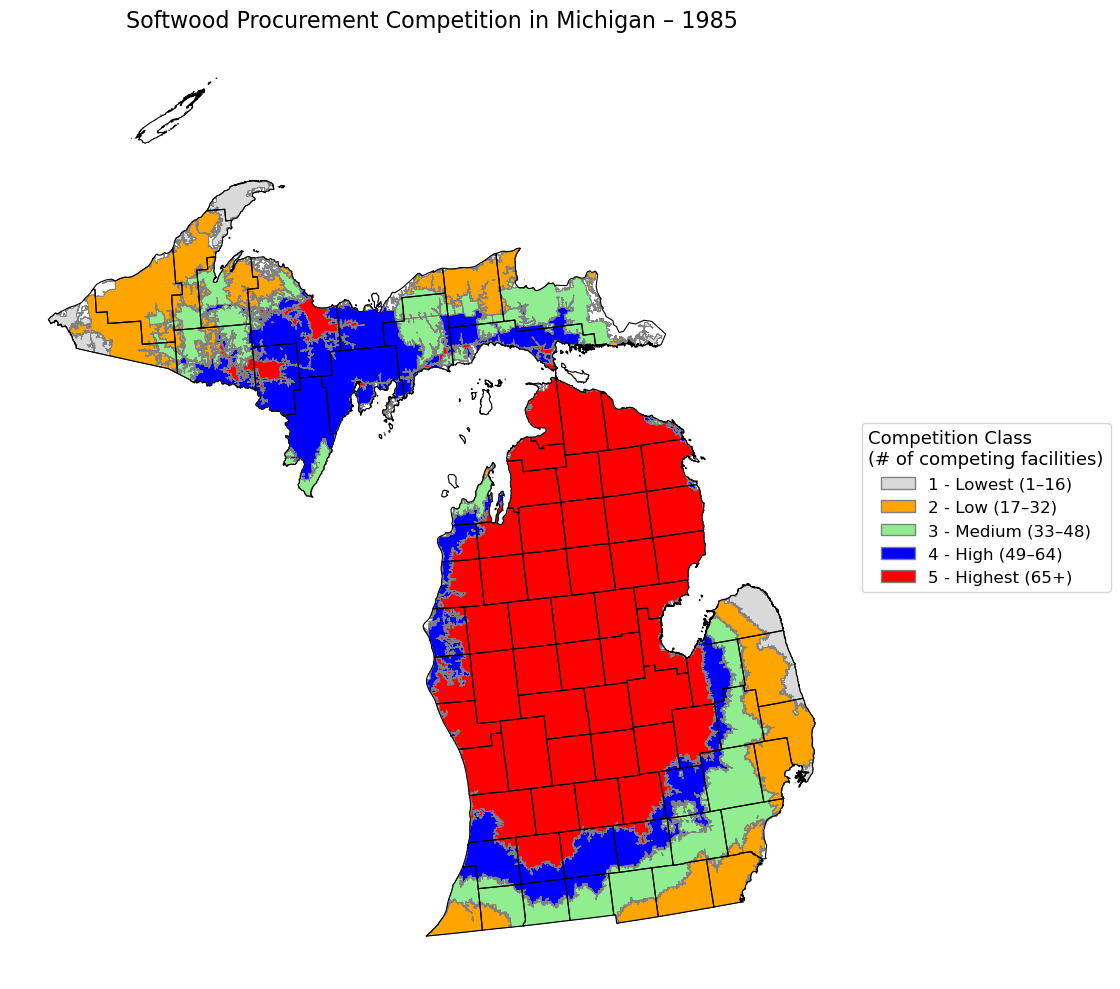

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# File paths for 1985
folder = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Khanal Manuscript Sept 2025\Hotspots Final"
michigan_fp = f"{folder}\\Michigan Counties.shp"
hotspot_fp_1985 = f"{folder}\\Softwood_1985_hotspots.shp"  # <-- change filename for 1985

# Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots_1985 = gpd.read_file(hotspot_fp_1985)

# Target CRS: ESRI:102010
target_crs = "ESRI:102010"

# Reproject Michigan counties to target CRS if needed
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# Reproject 1985 hotspots to target CRS if needed
if gdf_hotspots_1985.crs != target_crs:
    gdf_hotspots_1985 = gdf_hotspots_1985.to_crs(target_crs)

# Confirm 'CompValue' exists
if 'CompValue' not in gdf_hotspots_1985.columns:
    raise ValueError("The 'CompValue' column is not found in the 1985 hotspots shapefile!")

# Color mapping for competition classes
color_map = {
    'Lowest': '#D9D9D9',
    'Low': '#FFA500',
    'Medium': '#90EE90',
    'High': '#0000FF',
    'Highest': '#FF0000'
}

# Map colors to CompValue
gdf_hotspots_1985['color'] = gdf_hotspots_1985['CompValue'].map(color_map)

# Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan counties boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot 1985 hotspots with color fill and grey edges
gdf_hotspots_1985.plot(ax=ax, color=gdf_hotspots_1985['color'], edgecolor='grey', linewidth=0.5)

# Custom legend
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label='1 - Lowest (1–16)'),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label='2 - Low (17–32)'),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label='3 - Medium (33–48)'),
    Patch(facecolor=color_map['High'], edgecolor='grey', label='4 - High (49–64)'),
    Patch(facecolor=color_map['Highest'], edgecolor='grey', label='5 - Highest (65+)')
]

ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and axis clean-up
ax.set_title("Softwood Procurement Competition in Michigan – 1985", fontsize=16)
ax.set_axis_off()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


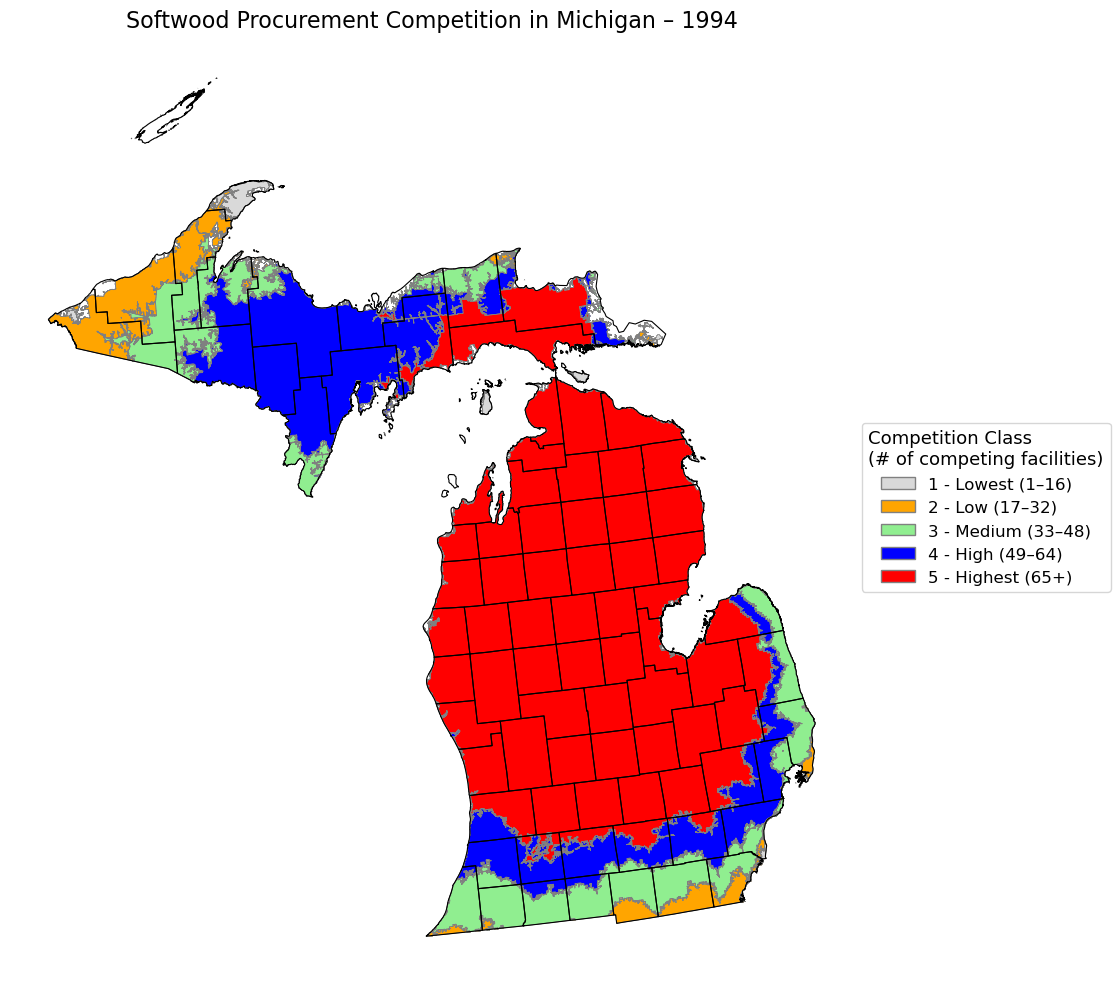

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# File paths
folder = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Khanal Manuscript Sept 2025\Hotspots Final"
michigan_fp = f"{folder}\\Michigan Counties.shp"
hotspot_fp = f"{folder}\\Softwood_1994_hotspots.shp"

# Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots = gpd.read_file(hotspot_fp)

# Target CRS: ESRI:102010 (from your raster)
target_crs = "ESRI:102010"

# Reproject Michigan counties to target CRS if needed
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# Reproject hotspots to target CRS if needed
if gdf_hotspots.crs != target_crs:
    gdf_hotspots = gdf_hotspots.to_crs(target_crs)

# Confirm 'CompValue' exists
if 'CompValue' not in gdf_hotspots.columns:
    raise ValueError("The 'CompValue' column is not found in the 1994 hotspots shapefile!")

# Color mapping for competition classes
color_map = {
    'Lowest': '#D9D9D9',
    'Low': '#FFA500',
    'Medium': '#90EE90',
    'High': '#0000FF',
    'Highest': '#FF0000'
}

# Map colors to CompValue (assuming 'CompValue' column has these exact keys)
gdf_hotspots['color'] = gdf_hotspots['CompValue'].map(color_map)

# Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan counties boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot hotspots with color fill and grey edges
gdf_hotspots.plot(ax=ax, color=gdf_hotspots['color'], edgecolor='grey', linewidth=0.5)

# Custom legend
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label='1 - Lowest (1–16)'),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label='2 - Low (17–32)'),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label='3 - Medium (33–48)'),
    Patch(facecolor=color_map['High'], edgecolor='grey', label='4 - High (49–64)'),
    Patch(facecolor=color_map['Highest'], edgecolor='grey', label='5 - Highest (65+)')
]

ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and axis clean-up
ax.set_title("Softwood Procurement Competition in Michigan – 1994", fontsize=16)
ax.set_axis_off()

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave room on right for legend
plt.show()


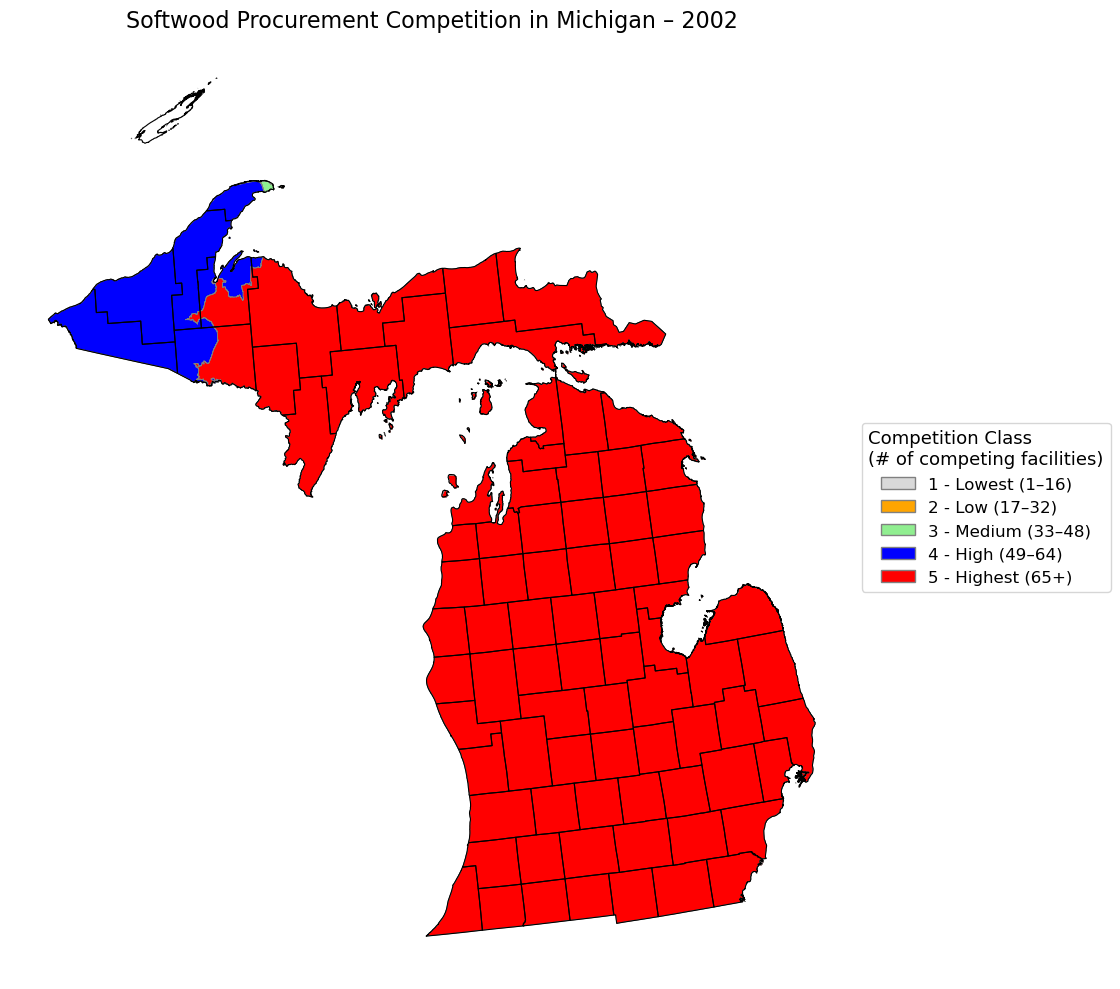

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# File paths for 2002
folder = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Khanal Manuscript Sept 2025\Hotspots Final"
michigan_fp = f"{folder}\\Michigan Counties.shp"
hotspot_fp_2002 = f"{folder}\\Softwood_2002_hotspots.shp"  # <-- update to 2002 shapefile

# Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots_2002 = gpd.read_file(hotspot_fp_2002)

# Target CRS: ESRI:102010
target_crs = "ESRI:102010"

# Reproject Michigan counties to target CRS if needed
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# Reproject 2002 hotspots to target CRS if needed
if gdf_hotspots_2002.crs != target_crs:
    gdf_hotspots_2002 = gdf_hotspots_2002.to_crs(target_crs)

# Confirm 'CompValue' exists
if 'CompValue' not in gdf_hotspots_2002.columns:
    raise ValueError("The 'CompValue' column is not found in the 2002 hotspots shapefile!")

# Color mapping for competition classes
color_map = {
    'Lowest': '#D9D9D9',
    'Low': '#FFA500',
    'Medium': '#90EE90',
    'High': '#0000FF',
    'Highest': '#FF0000'
}

# Map colors to CompValue
gdf_hotspots_2002['color'] = gdf_hotspots_2002['CompValue'].map(color_map)

# Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan counties boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot 2002 hotspots with color fill and grey edges
gdf_hotspots_2002.plot(ax=ax, color=gdf_hotspots_2002['color'], edgecolor='grey', linewidth=0.5)

# Custom legend
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label='1 - Lowest (1–16)'),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label='2 - Low (17–32)'),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label='3 - Medium (33–48)'),
    Patch(facecolor=color_map['High'], edgecolor='grey', label='4 - High (49–64)'),
    Patch(facecolor=color_map['Highest'], edgecolor='grey', label='5 - Highest (65+)')
]

ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and axis clean-up
ax.set_title("Softwood Procurement Competition in Michigan – 2002", fontsize=16)
ax.set_axis_off()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


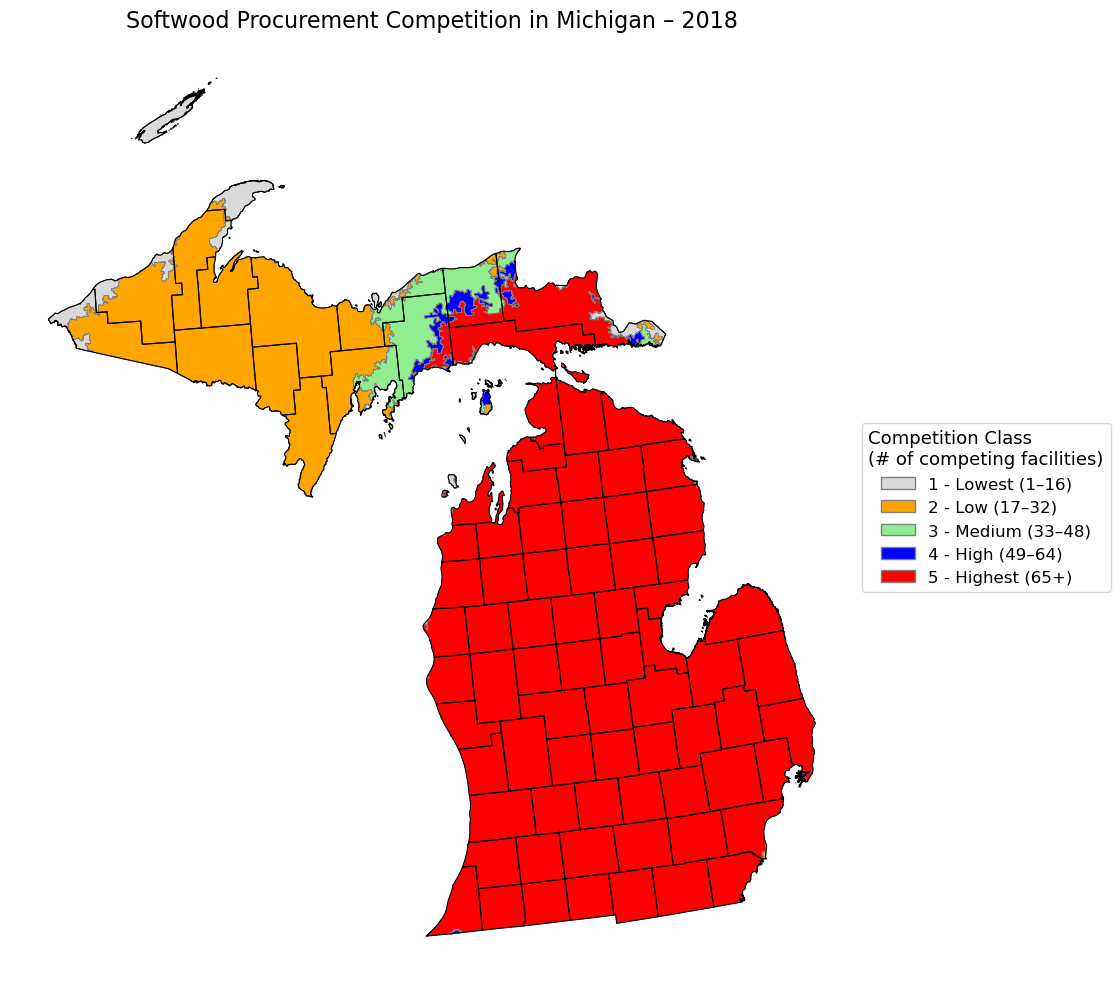

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# File paths for 2018
folder = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Khanal Manuscript Sept 2025\Hotspots Final"
michigan_fp = f"{folder}\\Michigan Counties.shp"
hotspot_fp_2018 = f"{folder}\\Softwood_2018_hotspots.shp"  # <-- update to 2018 shapefile

# Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots_2018 = gpd.read_file(hotspot_fp_2018)

# Target CRS: ESRI:102010
target_crs = "ESRI:102010"

# Reproject Michigan counties to target CRS if needed
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# Reproject 2018 hotspots to target CRS if needed
if gdf_hotspots_2018.crs != target_crs:
    gdf_hotspots_2018 = gdf_hotspots_2018.to_crs(target_crs)

# Confirm 'CompValue' exists
if 'CompValue' not in gdf_hotspots_2018.columns:
    raise ValueError("The 'CompValue' column is not found in the 2018 hotspots shapefile!")

# Color mapping for competition classes
color_map = {
    'Lowest': '#D9D9D9',
    'Low': '#FFA500',
    'Medium': '#90EE90',
    'High': '#0000FF',
    'Highest': '#FF0000'
}

# Map colors to CompValue
gdf_hotspots_2018['color'] = gdf_hotspots_2018['CompValue'].map(color_map)

# Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan counties boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot 2018 hotspots with color fill and grey edges
gdf_hotspots_2018.plot(ax=ax, color=gdf_hotspots_2018['color'], edgecolor='grey', linewidth=0.5)

# Custom legend
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label='1 - Lowest (1–16)'),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label='2 - Low (17–32)'),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label='3 - Medium (33–48)'),
    Patch(facecolor=color_map['High'], edgecolor='grey', label='4 - High (49–64)'),
    Patch(facecolor=color_map['Highest'], edgecolor='grey', label='5 - Highest (65+)')
]

ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and axis clean-up
ax.set_title("Softwood Procurement Competition in Michigan – 2018", fontsize=16)
ax.set_axis_off()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


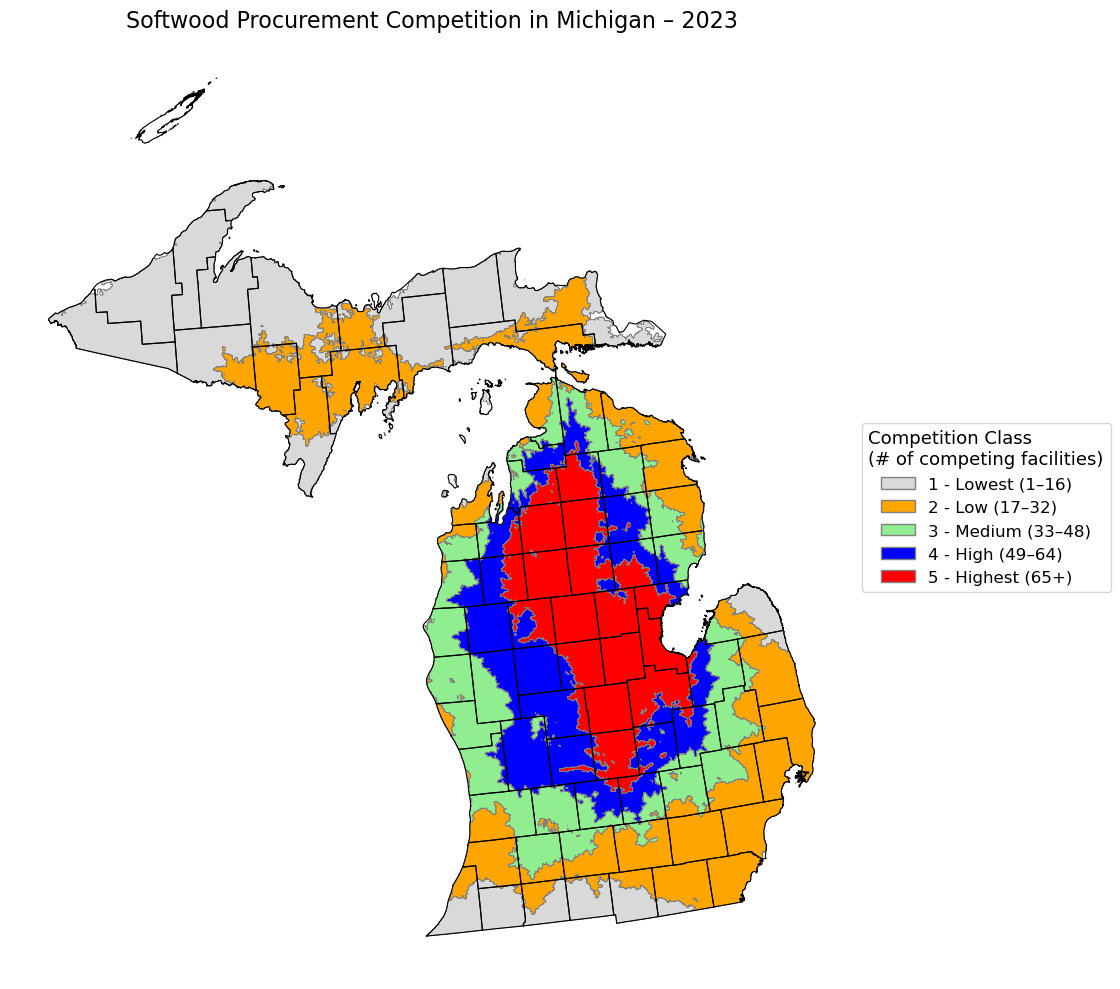

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# File paths for 2023
folder = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Khanal Manuscript Sept 2025\Hotspots Final"
michigan_fp = f"{folder}\\Michigan Counties.shp"
hotspot_fp_2023 = f"{folder}\\Softwood_2023_hotspots.shp"  # <-- update to 2023 shapefile

# Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots_2023 = gpd.read_file(hotspot_fp_2023)

# Target CRS: ESRI:102010
target_crs = "ESRI:102010"

# Reproject Michigan counties to target CRS if needed
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# Reproject 2023 hotspots to target CRS if needed
if gdf_hotspots_2023.crs != target_crs:
    gdf_hotspots_2023 = gdf_hotspots_2023.to_crs(target_crs)

# Confirm 'CompValue' exists
if 'CompValue' not in gdf_hotspots_2023.columns:
    raise ValueError("The 'CompValue' column is not found in the 2023 hotspots shapefile!")

# Color mapping for competition classes
color_map = {
    'Lowest': '#D9D9D9',
    'Low': '#FFA500',
    'Medium': '#90EE90',
    'High': '#0000FF',
    'Highest': '#FF0000'
}

# Map colors to CompValue
gdf_hotspots_2023['color'] = gdf_hotspots_2023['CompValue'].map(color_map)

# Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan counties boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot 2023 hotspots with color fill and grey edges
gdf_hotspots_2023.plot(ax=ax, color=gdf_hotspots_2023['color'], edgecolor='grey', linewidth=0.5)

# Custom legend
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label='1 - Lowest (1–16)'),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label='2 - Low (17–32)'),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label='3 - Medium (33–48)'),
    Patch(facecolor=color_map['High'], edgecolor='grey', label='4 - High (49–64)'),
    Patch(facecolor=color_map['Highest'], edgecolor='grey', label='5 - Highest (65+)')
]

ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and axis clean-up
ax.set_title("Softwood Procurement Competition in Michigan – 2023", fontsize=16)
ax.set_axis_off()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


# Hardwood

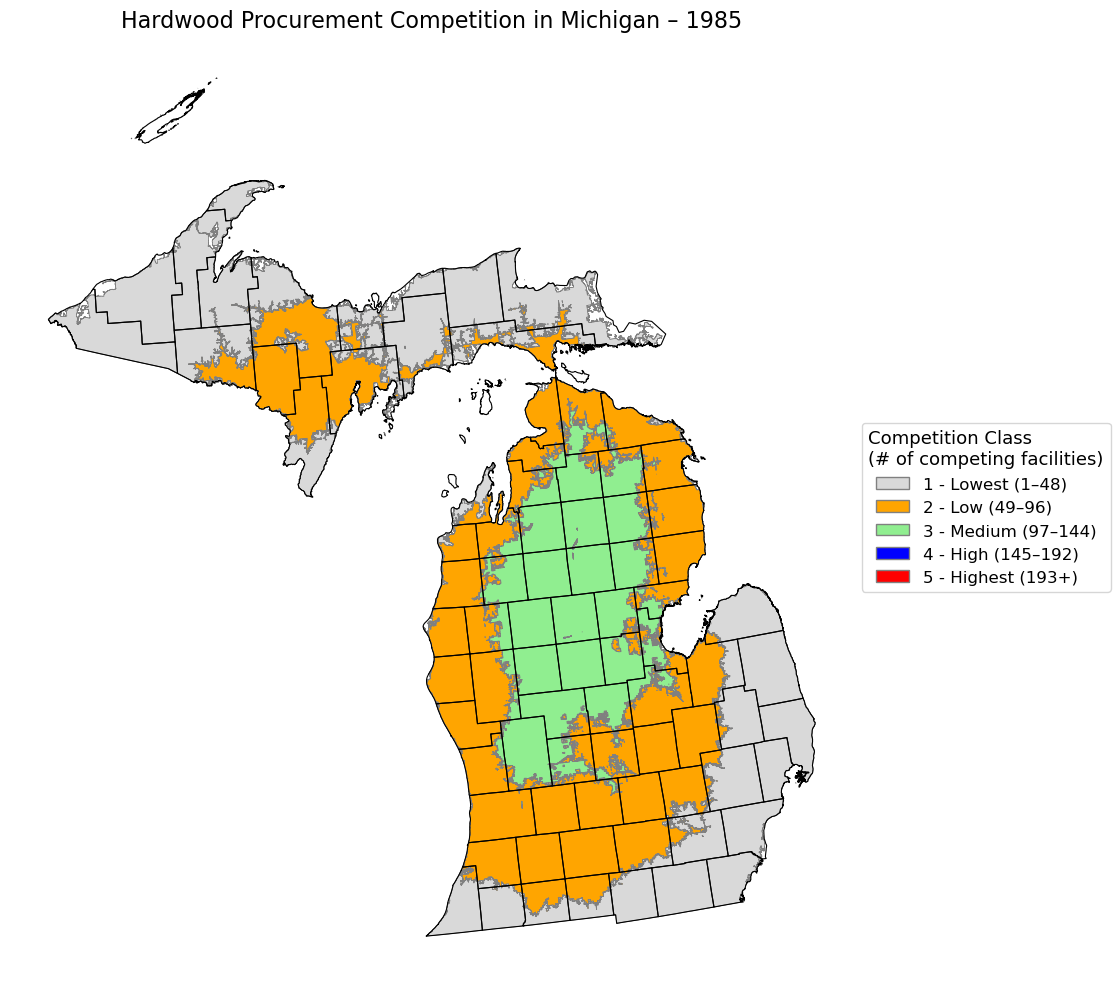

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# File paths
folder = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Khanal Manuscript Sept 2025\Hotspots Final"
michigan_fp = f"{folder}\\Michigan Counties.shp"
hotspot_fp = f"{folder}\\Hardwood_1985_hotspots.shp"

# Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots = gpd.read_file(hotspot_fp)

# Target CRS for consistent projection
target_crs = "ESRI:102010"

# Reproject Michigan counties if needed
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# Reproject Hardwood hotspots if needed
if gdf_hotspots.crs != target_crs:
    gdf_hotspots = gdf_hotspots.to_crs(target_crs)

# Check if 'CompValue' column exists
if 'CompValue' not in gdf_hotspots.columns:
    raise ValueError("The 'CompValue' column is not found in the 1985 hardwood hotspots shapefile!")

# Color mapping for competition classes
color_map = {
    'Lowest': '#D9D9D9',
    'Low': '#FFA500',
    'Medium': '#90EE90',
    'High': '#0000FF',
    'Highest': '#FF0000'
}

# Map colors to CompValue
gdf_hotspots['color'] = gdf_hotspots['CompValue'].map(color_map)

# Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan counties (boundaries only)
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot Hardwood 1985 hotspots with color
gdf_hotspots.plot(ax=ax, color=gdf_hotspots['color'], edgecolor='grey', linewidth=0.5)

# ✅ Legend for Hardwood competition classes
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label='1 - Lowest (1–48)'),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label='2 - Low (49–96)'),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label='3 - Medium (97–144)'),
    Patch(facecolor=color_map['High'], edgecolor='grey', label='4 - High (145–192)'),
    Patch(facecolor=color_map['Highest'], edgecolor='grey', label='5 - Highest (193+)')
]

# Add legend
ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and final layout
ax.set_title("Hardwood Procurement Competition in Michigan – 1985", fontsize=16)
ax.set_axis_off()
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


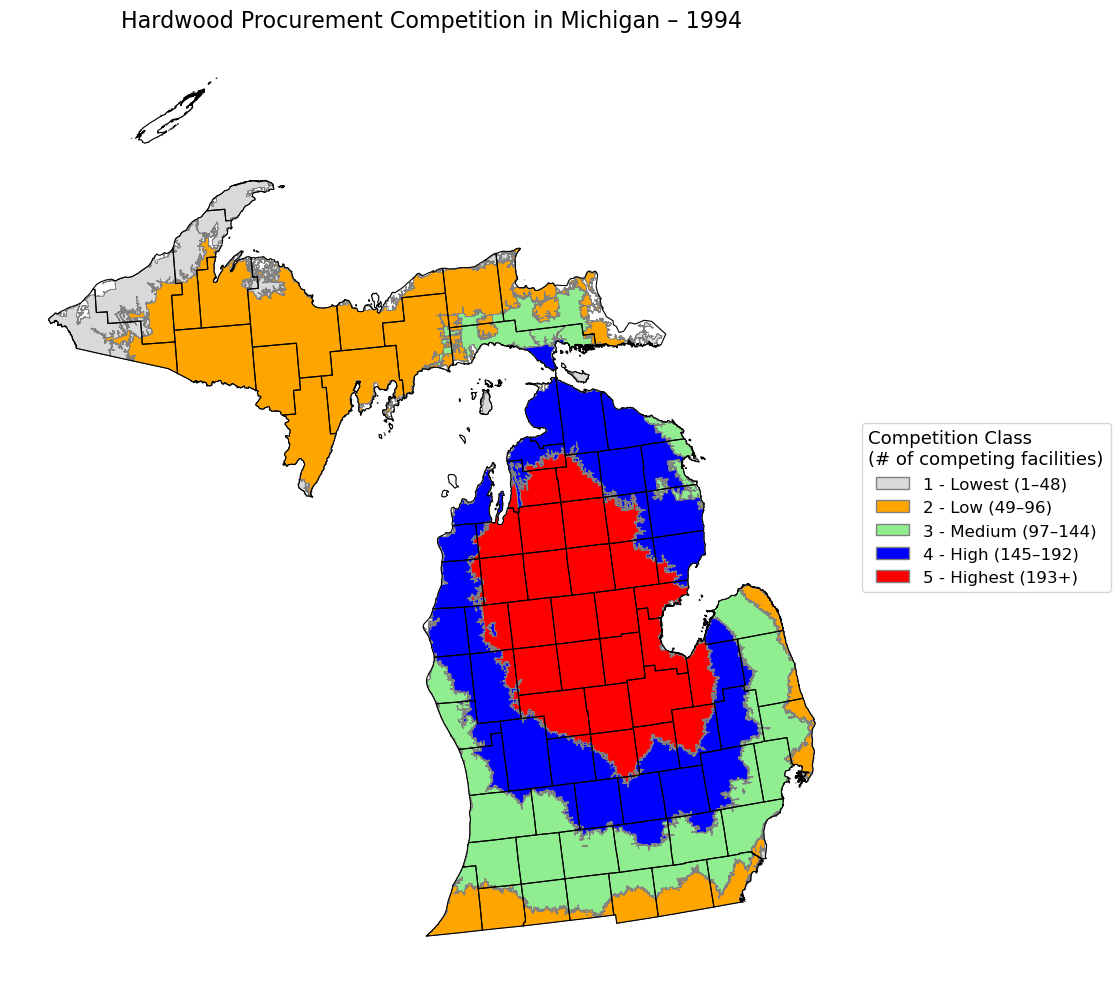

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# File paths
folder = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Khanal Manuscript Sept 2025\Hotspots Final"
michigan_fp = f"{folder}\\Michigan Counties.shp"
hotspot_fp = f"{folder}\\Hardwood_1994_hotspots.shp"

# Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots = gpd.read_file(hotspot_fp)

# Target CRS for consistent projection
target_crs = "ESRI:102010"

# Reproject Michigan counties if needed
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# Reproject Hardwood hotspots if needed
if gdf_hotspots.crs != target_crs:
    gdf_hotspots = gdf_hotspots.to_crs(target_crs)

# Check if 'CompValue' column exists
if 'CompValue' not in gdf_hotspots.columns:
    raise ValueError("The 'CompValue' column is not found in the 1994 hardwood hotspots shapefile!")

# Color mapping for competition classes
color_map = {
    'Lowest': '#D9D9D9',
    'Low': '#FFA500',
    'Medium': '#90EE90',
    'High': '#0000FF',
    'Highest': '#FF0000'
}

# Map colors to CompValue
gdf_hotspots['color'] = gdf_hotspots['CompValue'].map(color_map)

# Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan counties (boundaries only)
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot Hardwood 1994 hotspots with color
gdf_hotspots.plot(ax=ax, color=gdf_hotspots['color'], edgecolor='grey', linewidth=0.5)

# ✅ Legend for Hardwood competition classes
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label='1 - Lowest (1–48)'),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label='2 - Low (49–96)'),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label='3 - Medium (97–144)'),
    Patch(facecolor=color_map['High'], edgecolor='grey', label='4 - High (145–192)'),
    Patch(facecolor=color_map['Highest'], edgecolor='grey', label='5 - Highest (193+)')
]

# Add legend
ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and final layout
ax.set_title("Hardwood Procurement Competition in Michigan – 1994", fontsize=16)
ax.set_axis_off()
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


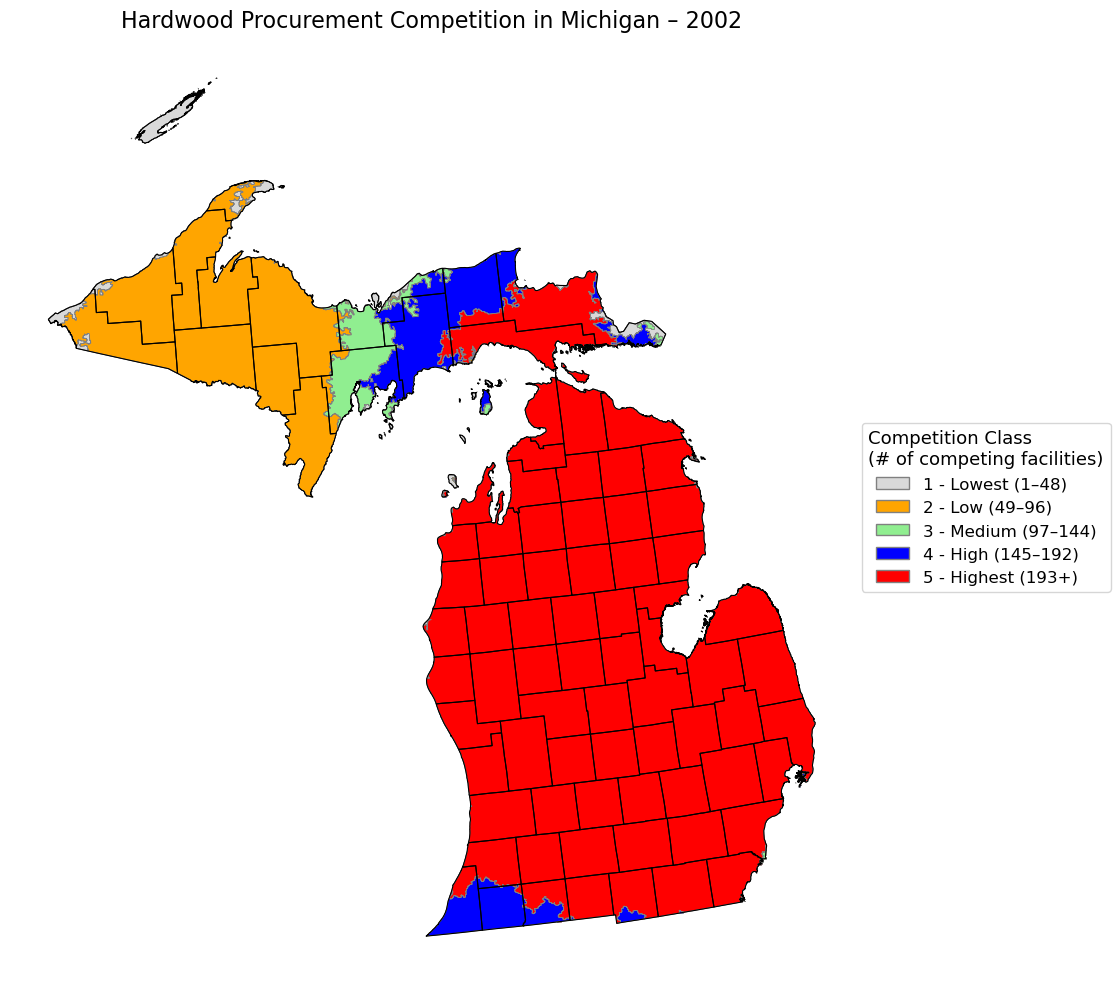

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# File paths
folder = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Khanal Manuscript Sept 2025\Hotspots Final"
michigan_fp = f"{folder}\\Michigan Counties.shp"
hotspot_fp = f"{folder}\\Hardwood_2002_hotspots.shp"

# Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots = gpd.read_file(hotspot_fp)

# Target CRS for consistent visualization (same as raster)
target_crs = "ESRI:102010"

# Reproject Michigan counties if needed
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# Reproject Hardwood hotspots if needed
if gdf_hotspots.crs != target_crs:
    gdf_hotspots = gdf_hotspots.to_crs(target_crs)

# Check for 'CompValue' column
if 'CompValue' not in gdf_hotspots.columns:
    raise ValueError("The 'CompValue' column is not found in the 2002 hardwood hotspots shapefile!")

# Color mapping for hardwood competition classes
color_map = {
    'Lowest': '#D9D9D9',
    'Low': '#FFA500',
    'Medium': '#90EE90',
    'High': '#0000FF',
    'Highest': '#FF0000'
}

# Assign colors based on CompValue
gdf_hotspots['color'] = gdf_hotspots['CompValue'].map(color_map)

# Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan county boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot hardwood hotspots
gdf_hotspots.plot(ax=ax, color=gdf_hotspots['color'], edgecolor='grey', linewidth=0.5)

# Legend for Hardwood competition classes
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label='1 - Lowest (1–48)'),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label='2 - Low (49–96)'),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label='3 - Medium (97–144)'),
    Patch(facecolor=color_map['High'], edgecolor='grey', label='4 - High (145–192)'),
    Patch(facecolor=color_map['Highest'], edgecolor='grey', label='5 - Highest (193+)')
]

# Add legend to the right
ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and layout
ax.set_title("Hardwood Procurement Competition in Michigan – 2002", fontsize=16)
ax.set_axis_off()
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave space for legend
plt.show()


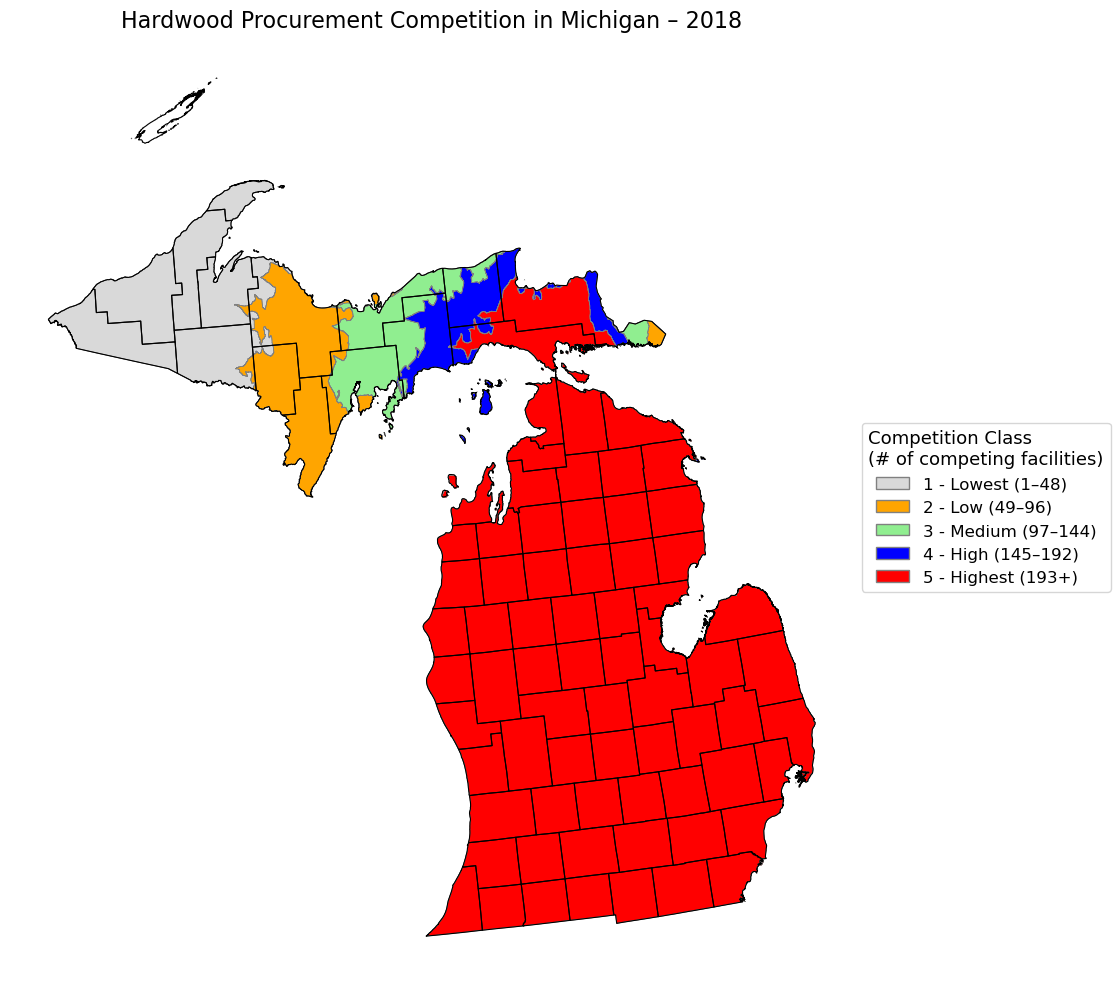

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# File paths
folder = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Khanal Manuscript Sept 2025\Hotspots Final"
michigan_fp = f"{folder}\\Michigan Counties.shp"
hotspot_fp = f"{folder}\\Hardwood_2018_hotspots.shp"

# Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots = gpd.read_file(hotspot_fp)

# Target CRS for consistent visualization (same as raster)
target_crs = "ESRI:102010"

# Reproject Michigan counties if needed
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# Reproject Hardwood hotspots if needed
if gdf_hotspots.crs != target_crs:
    gdf_hotspots = gdf_hotspots.to_crs(target_crs)

# Check for 'CompValue' column
if 'CompValue' not in gdf_hotspots.columns:
    raise ValueError("The 'CompValue' column is not found in the 2018 hardwood hotspots shapefile!")

# Color mapping for hardwood competition classes
color_map = {
    'Lowest': '#D9D9D9',
    'Low': '#FFA500',
    'Medium': '#90EE90',
    'High': '#0000FF',
    'Highest': '#FF0000'
}

# Assign colors based on CompValue
gdf_hotspots['color'] = gdf_hotspots['CompValue'].map(color_map)

# Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan county boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot hardwood hotspots
gdf_hotspots.plot(ax=ax, color=gdf_hotspots['color'], edgecolor='grey', linewidth=0.5)

# Legend for Hardwood competition classes
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label='1 - Lowest (1–48)'),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label='2 - Low (49–96)'),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label='3 - Medium (97–144)'),
    Patch(facecolor=color_map['High'], edgecolor='grey', label='4 - High (145–192)'),
    Patch(facecolor=color_map['Highest'], edgecolor='grey', label='5 - Highest (193+)')
]

# Add legend to the right
ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and layout
ax.set_title("Hardwood Procurement Competition in Michigan – 2018", fontsize=16)
ax.set_axis_off()
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave space for legend
plt.show()


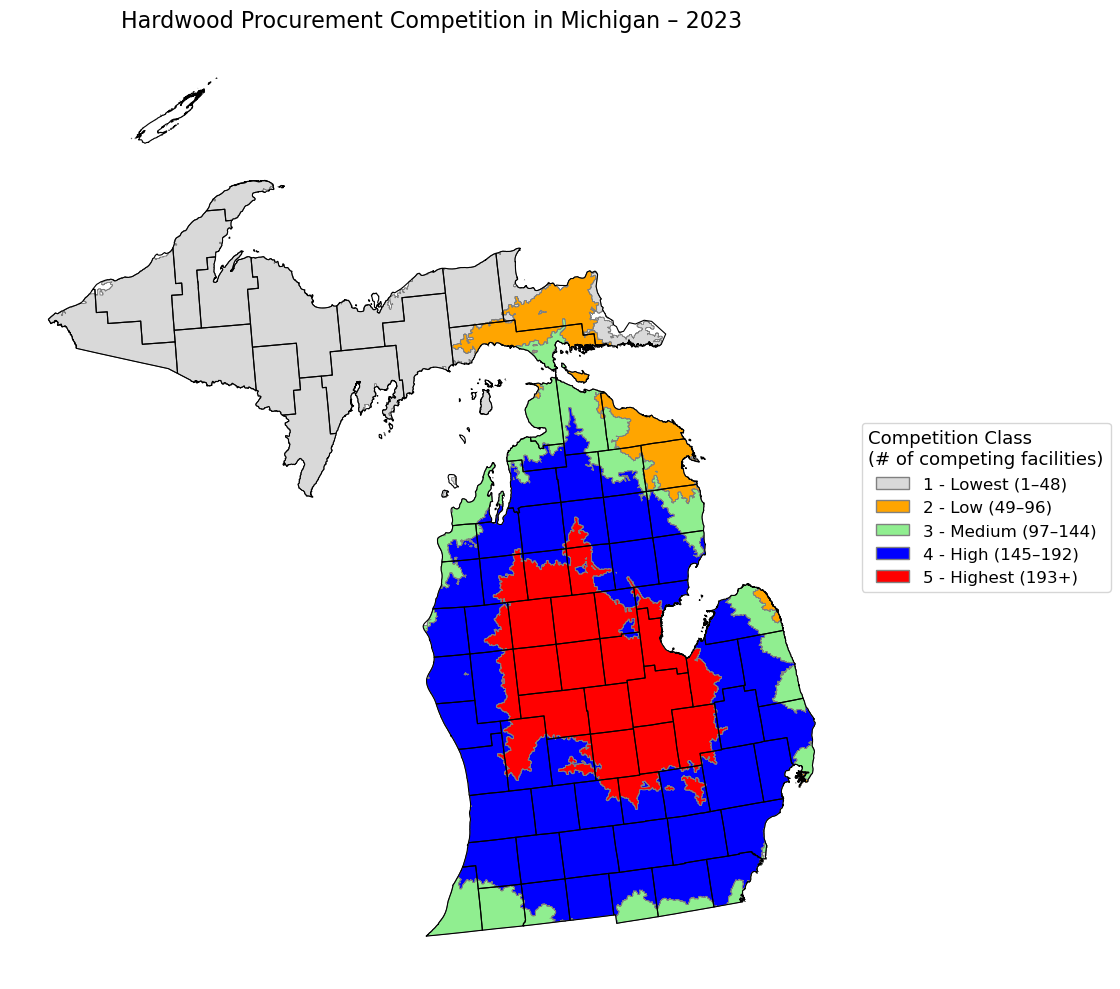

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# File paths
folder = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Khanal Manuscript Sept 2025\Hotspots Final"
michigan_fp = f"{folder}\\Michigan Counties.shp"
hotspot_fp = f"{folder}\\Hardwood_2023_hotspots.shp"

# Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots = gpd.read_file(hotspot_fp)

# Target projection (CRS) – same as raster display style
target_crs = "ESRI:102010"

# Reproject Michigan counties if needed
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# Reproject hotspots if needed
if gdf_hotspots.crs != target_crs:
    gdf_hotspots = gdf_hotspots.to_crs(target_crs)

# Check for 'CompValue' column
if 'CompValue' not in gdf_hotspots.columns:
    raise ValueError("The 'CompValue' column is not found in the 2023 hardwood hotspots shapefile!")

# Color mapping for Hardwood competition classes
color_map = {
    'Lowest': '#D9D9D9',
    'Low': '#FFA500',
    'Medium': '#90EE90',
    'High': '#0000FF',
    'Highest': '#FF0000'
}

# Apply color based on CompValue
gdf_hotspots['color'] = gdf_hotspots['CompValue'].map(color_map)

# Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan county boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot hardwood hotspots
gdf_hotspots.plot(ax=ax, color=gdf_hotspots['color'], edgecolor='grey', linewidth=0.5)

# Legend for Hardwood competition classes
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label='1 - Lowest (1–48)'),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label='2 - Low (49–96)'),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label='3 - Medium (97–144)'),
    Patch(facecolor=color_map['High'], edgecolor='grey', label='4 - High (145–192)'),
    Patch(facecolor=color_map['Highest'], edgecolor='grey', label='5 - Highest (193+)')
]

# Add legend
ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Final layout and title
ax.set_title("Hardwood Procurement Competition in Michigan – 2023", fontsize=16)
ax.set_axis_off()
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave space for legend
plt.show()


# Biomass

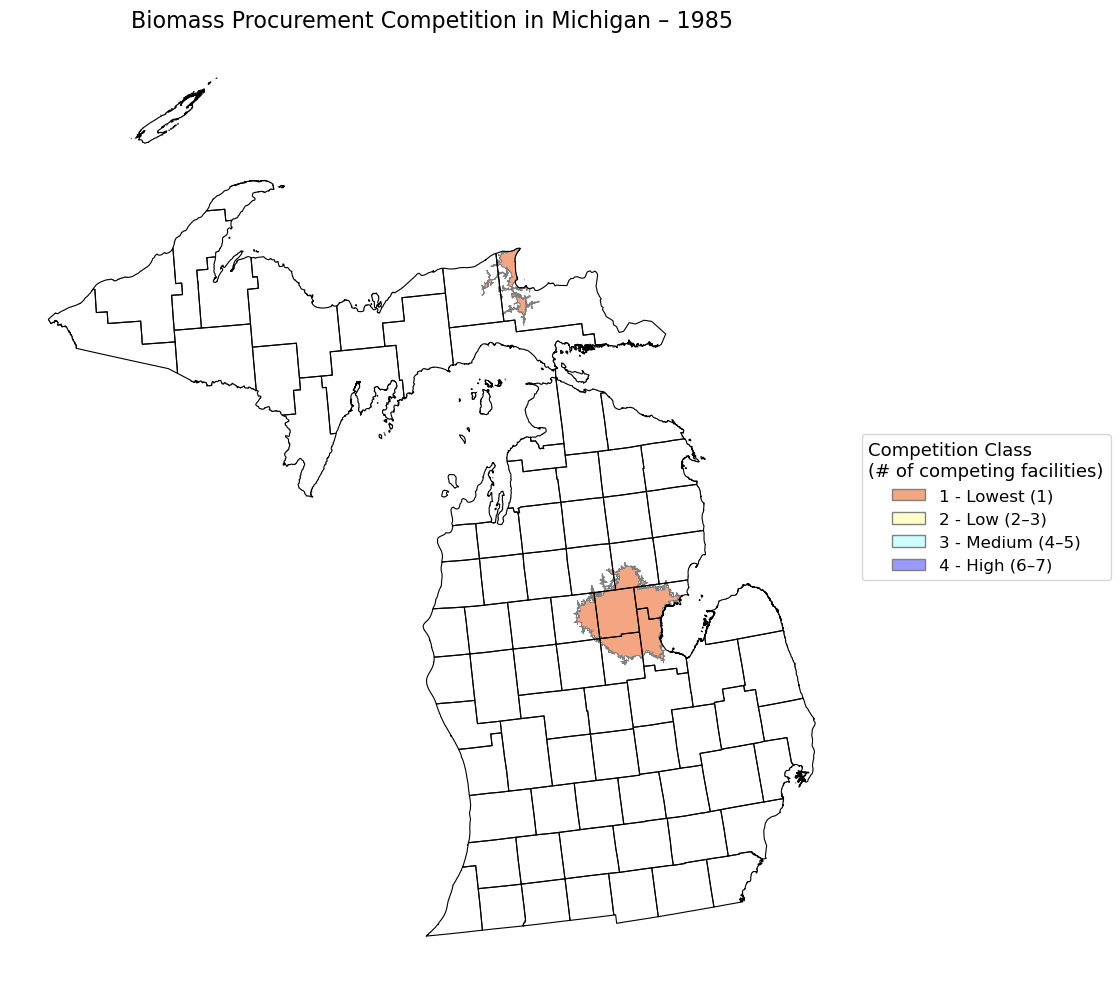

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# File paths
folder = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Khanal Manuscript Sept 2025\Hotspots Final"
michigan_fp = f"{folder}\\Michigan Counties.shp"
hotspot_fp = f"{folder}\\Biomass_1985_hotspots.shp"

# Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots = gpd.read_file(hotspot_fp)

# Target CRS = ESRI:102010 (North America Equidistant Conic)
target_crs = "ESRI:102010"

# Reproject Michigan if necessary
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# Reproject biomass hotspots if necessary
if gdf_hotspots.crs != target_crs:
    gdf_hotspots = gdf_hotspots.to_crs(target_crs)

# Make sure 'CompValue' or similar column exists
if 'CompValue' not in gdf_hotspots.columns:
    raise ValueError("The 'CompValue' column is not found in the Biomass 1985 hotspots shapefile!")

# Color mapping for biomass classes
color_map = {
    'Lowest': "#F4A582",
    'Low':    "#FFFFCC",
    'Medium': "#CCFFFF",
    'High':   "#9999FF"
}

# Map colors to CompValue (assuming CompValue has exactly these categorical values: "Lowest", "Low", "Medium", "High")
gdf_hotspots['color'] = gdf_hotspots['CompValue'].map(color_map)

# Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan county boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot biomass hotspots with color fill and grey edges
gdf_hotspots.plot(ax=ax, color=gdf_hotspots['color'], edgecolor='grey', linewidth=0.5)

# Legend for biomass competition classes
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor=color_map['High'], edgecolor='grey', label="4 - High (6–7)")
]

ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and layout
ax.set_title("Biomass Procurement Competition in Michigan – 1985", fontsize=16)
ax.set_axis_off()
plt.tight_layout(rect=[0, 0, 0.85, 1])  # leave space on right for legend
plt.show()


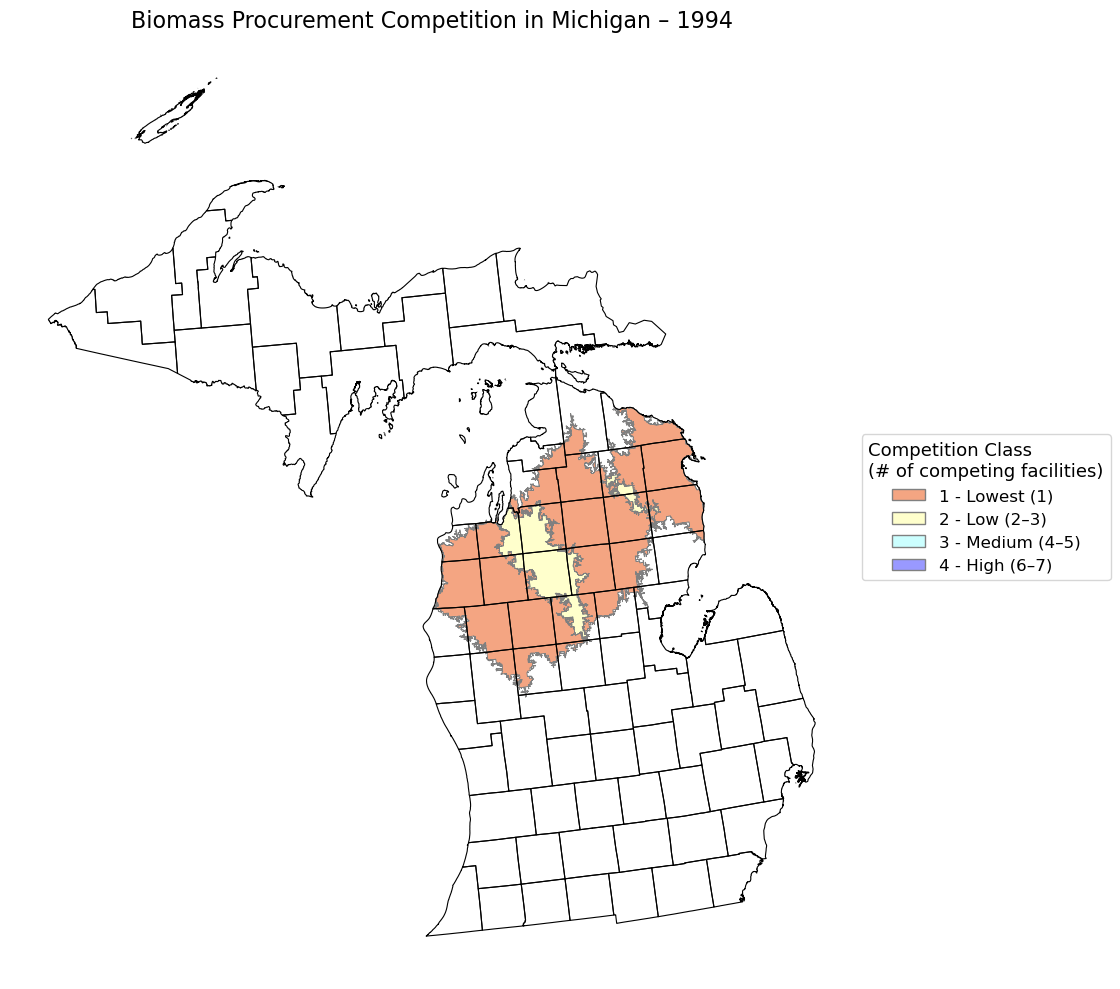

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# File paths
folder = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Khanal Manuscript Sept 2025\Hotspots Final"
michigan_fp = f"{folder}\\Michigan Counties.shp"
hotspot_fp = f"{folder}\\Biomass_1994_hotspots.shp"

# Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots = gpd.read_file(hotspot_fp)

# Target CRS: ESRI:102010
target_crs = "ESRI:102010"

# Reproject Michigan counties
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

# Reproject biomass hotspots
if gdf_hotspots.crs != target_crs:
    gdf_hotspots = gdf_hotspots.to_crs(target_crs)

# Check for 'CompValue' column
if 'CompValue' not in gdf_hotspots.columns:
    raise ValueError("The 'CompValue' column is not found in the Biomass 1994 hotspots shapefile!")

# Biomass color classification
color_map = {
    'Lowest': "#F4A582",
    'Low':    "#FFFFCC",
    'Medium': "#CCFFFF",
    'High':   "#9999FF"
}

# Map colors to competition values
gdf_hotspots['color'] = gdf_hotspots['CompValue'].map(color_map)

# Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot Michigan counties (boundary only)
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot biomass hotspots
gdf_hotspots.plot(ax=ax, color=gdf_hotspots['color'], edgecolor='grey', linewidth=0.5)

# Legend for biomass competition classes
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor=color_map['High'], edgecolor='grey', label="4 - High (6–7)")
]

# Add legend
ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and layout
ax.set_title("Biomass Procurement Competition in Michigan – 1994", fontsize=16)
ax.set_axis_off()
plt.tight_layout(rect=[0, 0, 0.85, 1])  # room for legend
plt.show()


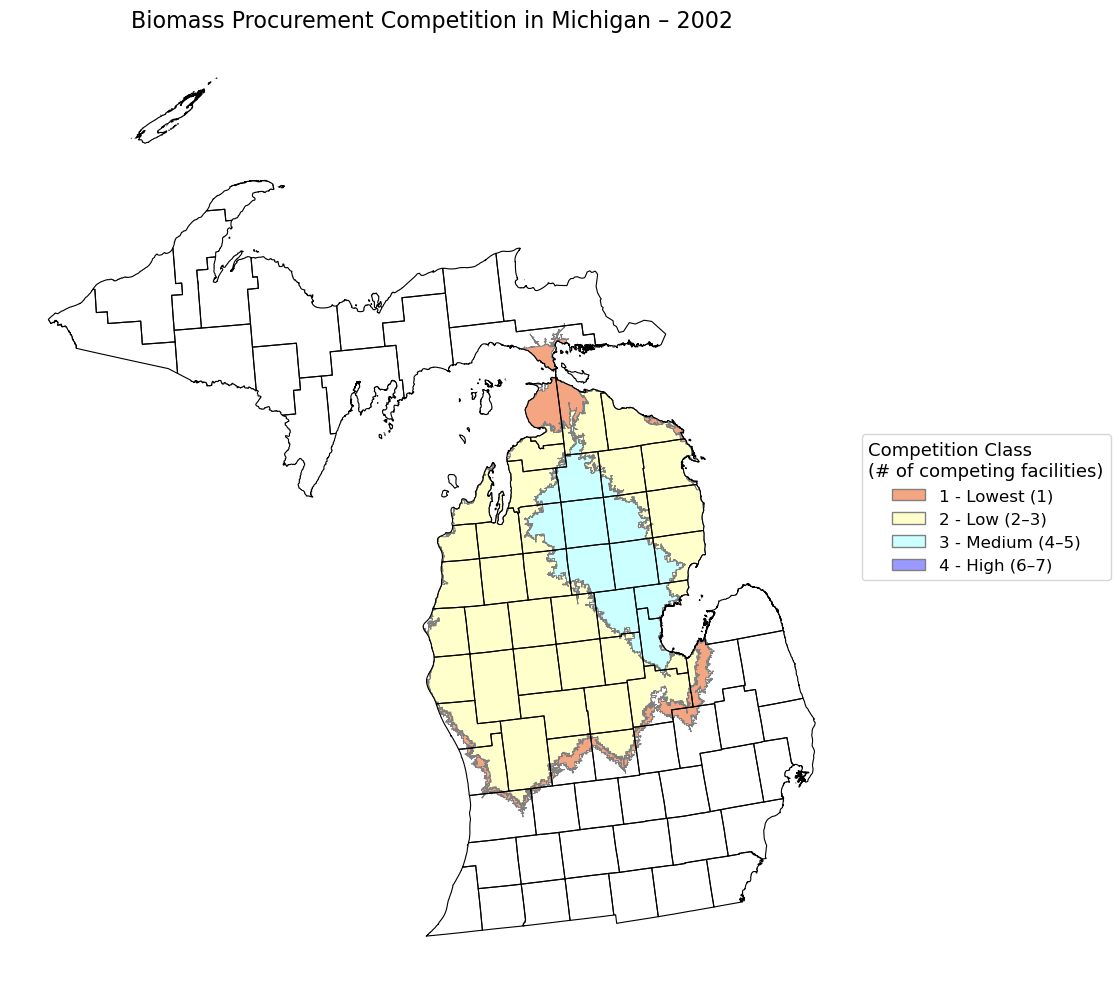

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# File paths
folder = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Khanal Manuscript Sept 2025\Hotspots Final"
michigan_fp = f"{folder}\\Michigan Counties.shp"
hotspot_fp = f"{folder}\\Biomass_2002_hotspots.shp"

# Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots = gpd.read_file(hotspot_fp)

# Target CRS: ESRI:102010
target_crs = "ESRI:102010"

# Reproject if needed
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

if gdf_hotspots.crs != target_crs:
    gdf_hotspots = gdf_hotspots.to_crs(target_crs)

# Ensure 'CompValue' exists
if 'CompValue' not in gdf_hotspots.columns:
    raise ValueError("The 'CompValue' column is missing in the Biomass 2002 hotspots shapefile!")

# Color mapping
color_map = {
    'Lowest': "#F4A582",
    'Low':    "#FFFFCC",
    'Medium': "#CCFFFF",
    'High':   "#9999FF"
}

# Map colors
gdf_hotspots['color'] = gdf_hotspots['CompValue'].map(color_map)

# Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot county boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot hotspots
gdf_hotspots.plot(ax=ax, color=gdf_hotspots['color'], edgecolor='grey', linewidth=0.5)

# Legend
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor=color_map['High'], edgecolor='grey', label="4 - High (6–7)")
]

ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and layout
ax.set_title("Biomass Procurement Competition in Michigan – 2002", fontsize=16)
ax.set_axis_off()
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


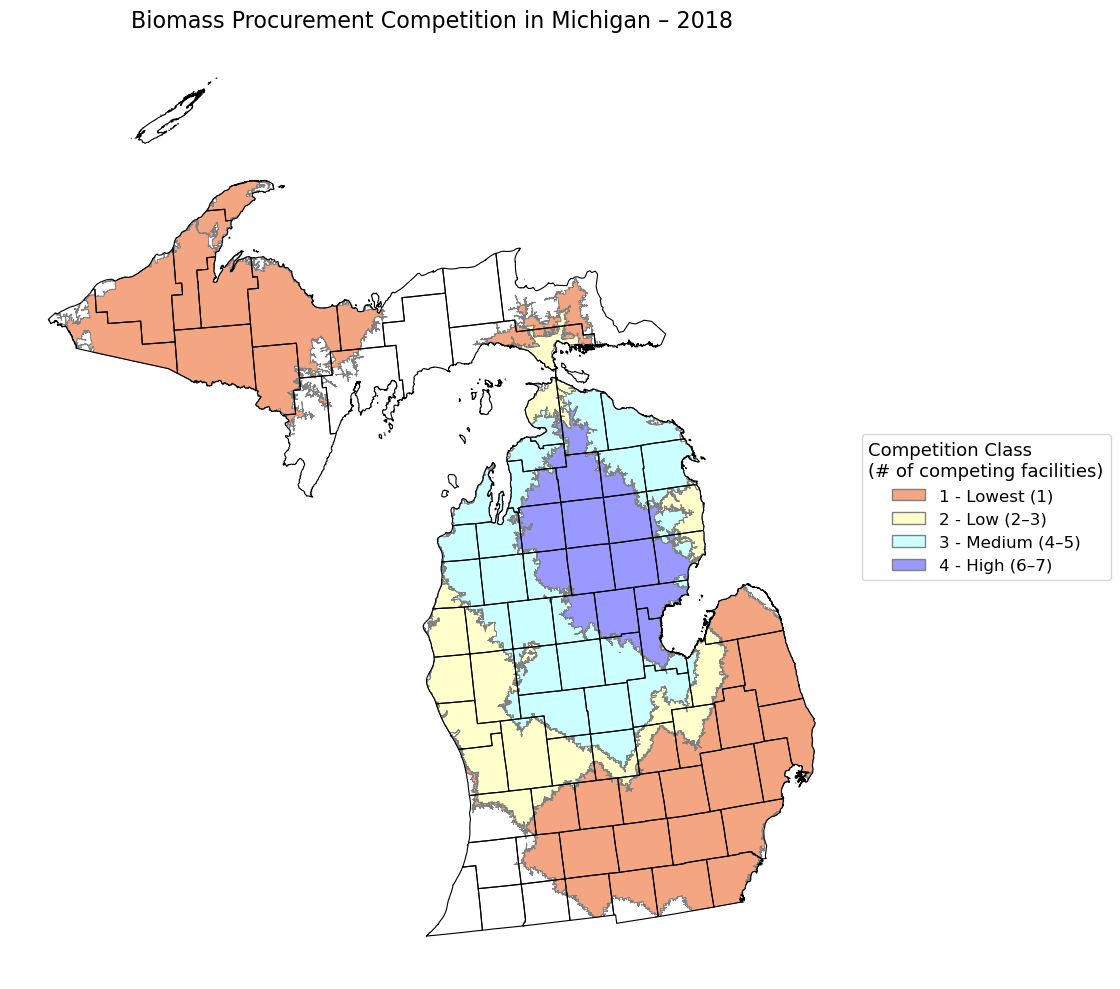

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# File paths
folder = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Khanal Manuscript Sept 2025\Hotspots Final"
michigan_fp = f"{folder}\\Michigan Counties.shp"
hotspot_fp = f"{folder}\\Biomass_2018_hotspots.shp"

# Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots = gpd.read_file(hotspot_fp)

# Target CRS: ESRI:102010
target_crs = "ESRI:102010"

# Reproject if needed
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

if gdf_hotspots.crs != target_crs:
    gdf_hotspots = gdf_hotspots.to_crs(target_crs)

# Ensure 'CompValue' exists
if 'CompValue' not in gdf_hotspots.columns:
    raise ValueError("The 'CompValue' column is missing in the Biomass 2018 hotspots shapefile!")

# Color mapping
color_map = {
    'Lowest': "#F4A582",
    'Low':    "#FFFFCC",
    'Medium': "#CCFFFF",
    'High':   "#9999FF"
}

# Map colors
gdf_hotspots['color'] = gdf_hotspots['CompValue'].map(color_map)

# Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Plot county boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot hotspots
gdf_hotspots.plot(ax=ax, color=gdf_hotspots['color'], edgecolor='grey', linewidth=0.5)

# Legend
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor=color_map['High'], edgecolor='grey', label="4 - High (6–7)")
]

ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and layout
ax.set_title("Biomass Procurement Competition in Michigan – 2018", fontsize=16)
ax.set_axis_off()
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


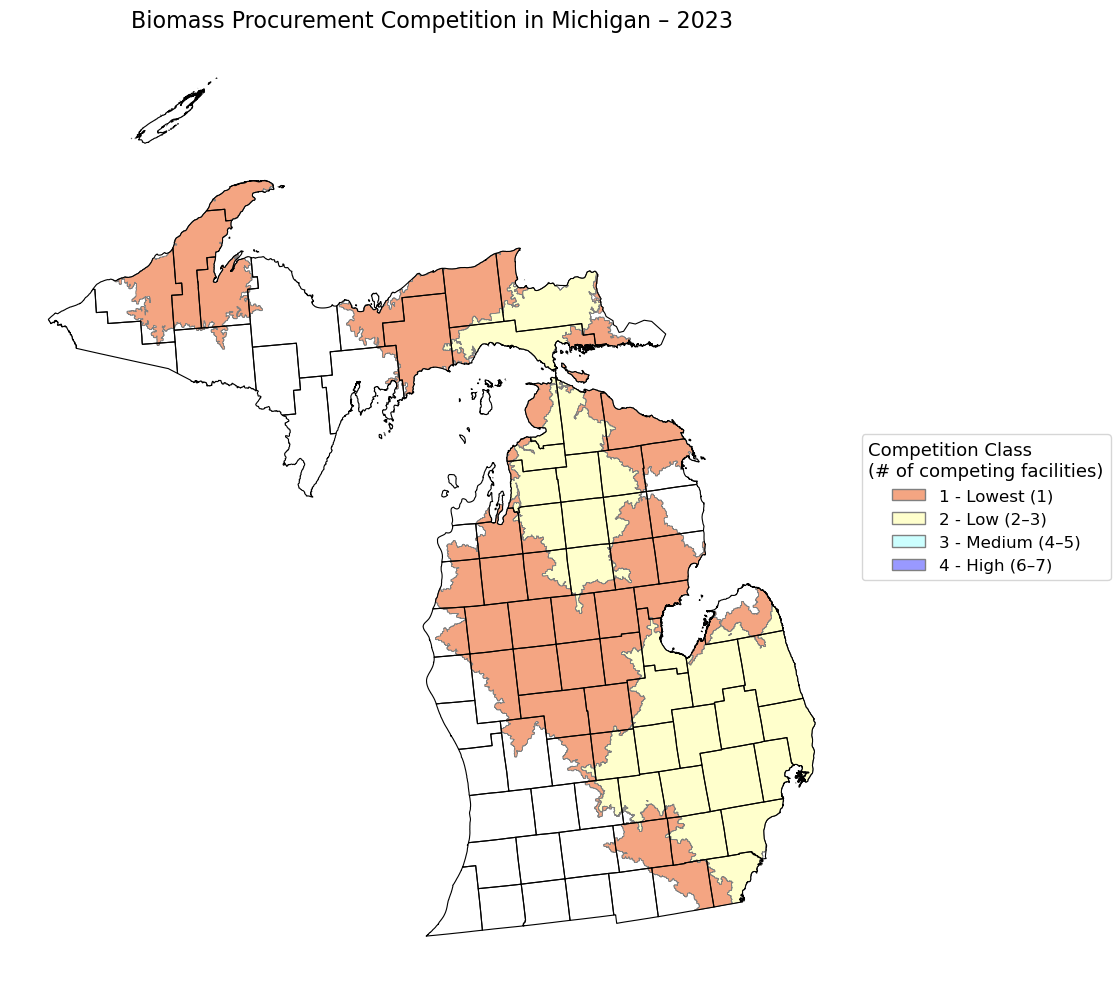

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# File paths
folder = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Khanal Manuscript Sept 2025\Hotspots Final"
michigan_fp = f"{folder}\\Michigan Counties.shp"
hotspot_fp = f"{folder}\\Biomass_2023_hotspots.shp"

# Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots = gpd.read_file(hotspot_fp)

# Target CRS: ESRI:102010
target_crs = "ESRI:102010"

# Reproject if needed
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

if gdf_hotspots.crs != target_crs:
    gdf_hotspots = gdf_hotspots.to_crs(target_crs)

# Check 'CompValue' column presence
if 'CompValue' not in gdf_hotspots.columns:
    raise ValueError("The 'CompValue' column is missing in the Biomass 2023 hotspots shapefile!")

# Color mapping
color_map = {
    'Lowest': "#F4A582",
    'Low':    "#FFFFCC",
    'Medium': "#CCFFFF",
    'High':   "#9999FF"
}

# Map colors
gdf_hotspots['color'] = gdf_hotspots['CompValue'].map(color_map)

# Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Michigan counties boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Hotspots
gdf_hotspots.plot(ax=ax, color=gdf_hotspots['color'], edgecolor='grey', linewidth=0.5)

# Legend
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor=color_map['High'], edgecolor='grey', label="4 - High (6–7)")
]

ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and layout
ax.set_title("Biomass Procurement Competition in Michigan – 2023", fontsize=16)
ax.set_axis_off()
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


# Pulpwood

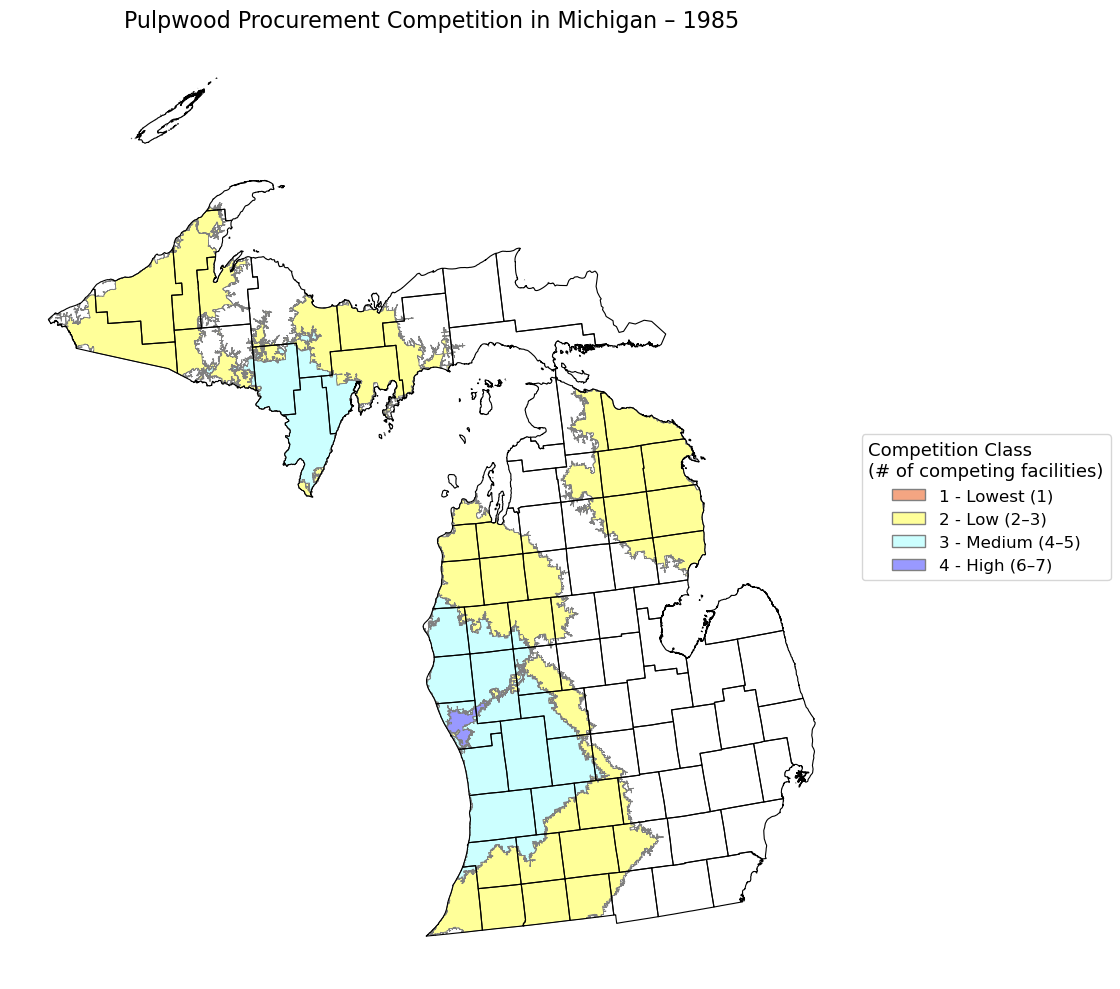

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# File paths
folder = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Khanal Manuscript Sept 2025\Hotspots Final"
michigan_fp = f"{folder}\\Michigan Counties.shp"
hotspot_fp = f"{folder}\\Pulpwood_1985_hotspots.shp"

# Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots = gpd.read_file(hotspot_fp)

# Target CRS: ESRI:102010
target_crs = "ESRI:102010"

# Reproject if needed
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

if gdf_hotspots.crs != target_crs:
    gdf_hotspots = gdf_hotspots.to_crs(target_crs)

# Check 'CompValue' column presence
if 'CompValue' not in gdf_hotspots.columns:
    raise ValueError("The 'CompValue' column is missing in the Pulpwood 1985 hotspots shapefile!")

# Color mapping with updated '#ffff99' for Low class
color_map = {
    'Lowest': "#F4A582",
    'Low':    "#FFFF99",   # updated color here
    'Medium': "#CCFFFF",
    'High':   "#9999FF"
}

# Map colors to CompValue
gdf_hotspots['color'] = gdf_hotspots['CompValue'].map(color_map)

# Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Michigan counties boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot hotspots
gdf_hotspots.plot(ax=ax, color=gdf_hotspots['color'], edgecolor='grey', linewidth=0.5)

# Legend
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor=color_map['High'], edgecolor='grey', label="4 - High (6–7)")
]

ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and layout
ax.set_title("Pulpwood Procurement Competition in Michigan – 1985", fontsize=16)
ax.set_axis_off()
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


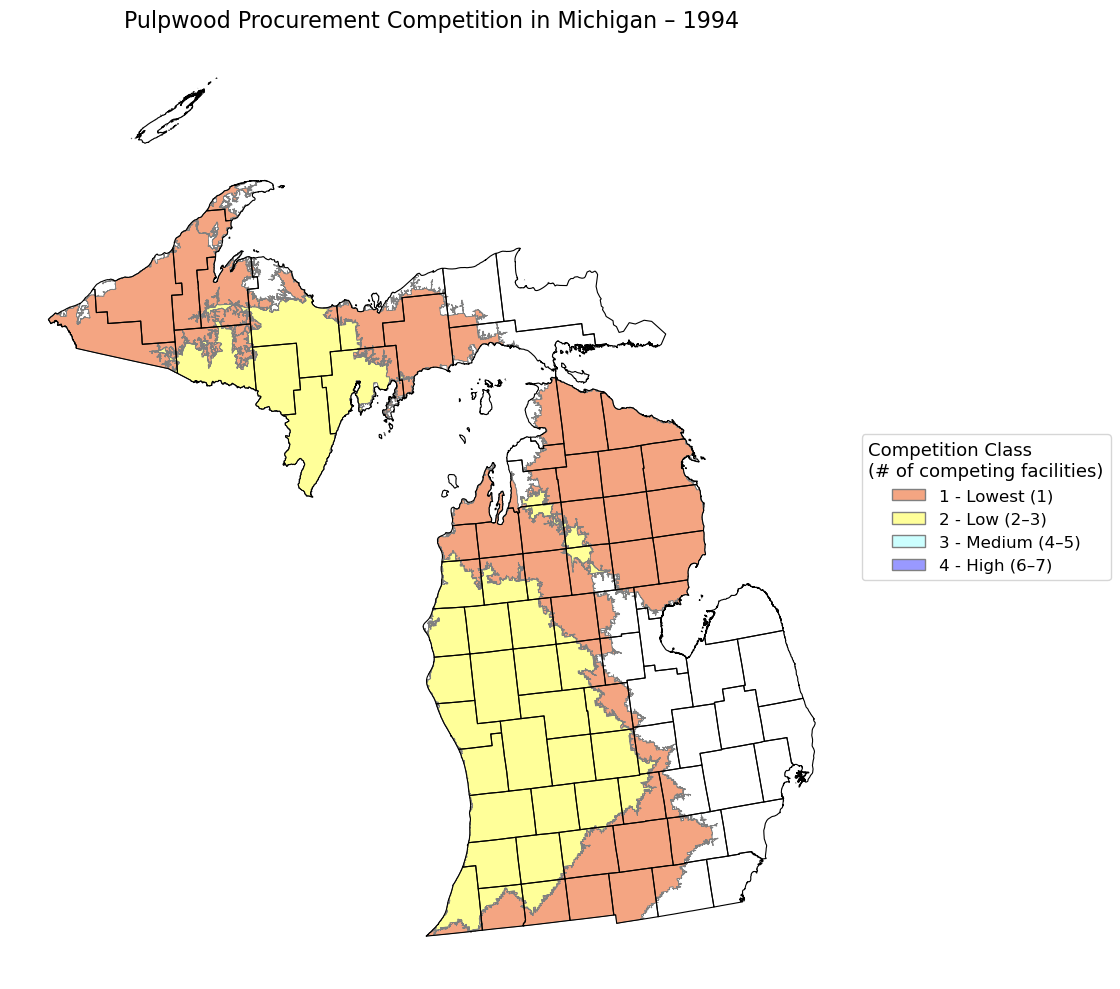

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# File paths
folder = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Khanal Manuscript Sept 2025\Hotspots Final"
michigan_fp = f"{folder}\\Michigan Counties.shp"
hotspot_fp = f"{folder}\\Pulpwood_1994_hotspots.shp"

# Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots = gpd.read_file(hotspot_fp)

# Target CRS: ESRI:102010
target_crs = "ESRI:102010"

# Reproject if needed
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

if gdf_hotspots.crs != target_crs:
    gdf_hotspots = gdf_hotspots.to_crs(target_crs)

# Check 'CompValue' column presence
if 'CompValue' not in gdf_hotspots.columns:
    raise ValueError("The 'CompValue' column is missing in the Pulpwood 1994 hotspots shapefile!")

# Color mapping with updated '#ffff99' for Low class
color_map = {
    'Lowest': "#F4A582",
    'Low':    "#FFFF99",   # updated color here
    'Medium': "#CCFFFF",
    'High':   "#9999FF"
}

# Map colors to CompValue
gdf_hotspots['color'] = gdf_hotspots['CompValue'].map(color_map)

# Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Michigan counties boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot hotspots
gdf_hotspots.plot(ax=ax, color=gdf_hotspots['color'], edgecolor='grey', linewidth=0.5)

# Legend
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor=color_map['High'], edgecolor='grey', label="4 - High (6–7)")
]

ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and layout
ax.set_title("Pulpwood Procurement Competition in Michigan – 1994", fontsize=16)
ax.set_axis_off()
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


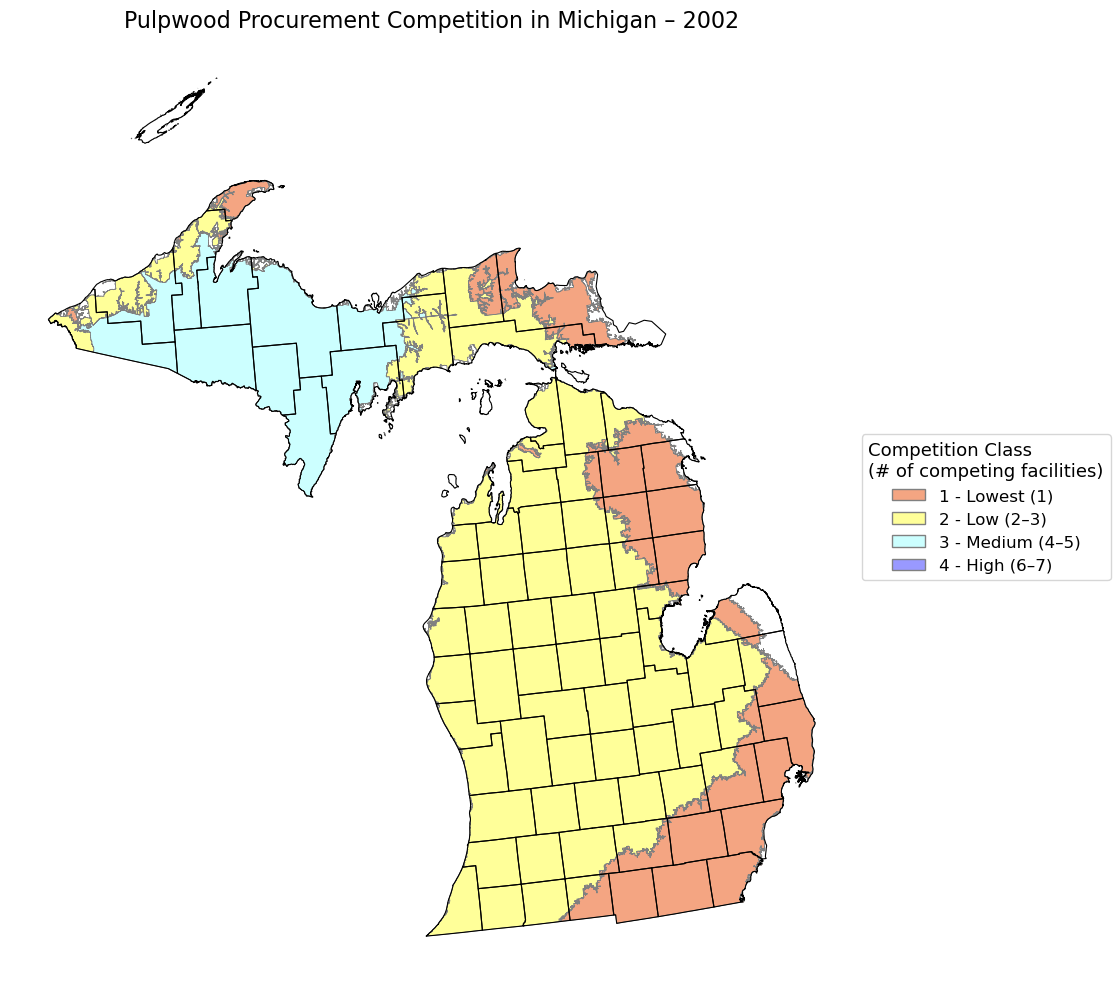

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# File paths
folder = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Khanal Manuscript Sept 2025\Hotspots Final"
michigan_fp = f"{folder}\\Michigan Counties.shp"
hotspot_fp = f"{folder}\\Pulpwood_2002_hotspots.shp"

# Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots = gpd.read_file(hotspot_fp)

# Target CRS: ESRI:102010
target_crs = "ESRI:102010"

# Reproject if needed
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

if gdf_hotspots.crs != target_crs:
    gdf_hotspots = gdf_hotspots.to_crs(target_crs)

# Check 'CompValue' column presence
if 'CompValue' not in gdf_hotspots.columns:
    raise ValueError("The 'CompValue' column is missing in the Pulpwood 2002 hotspots shapefile!")

# Color mapping with updated '#FFFF99' for Low class
color_map = {
    'Lowest': "#F4A582",
    'Low':    "#FFFF99",
    'Medium': "#CCFFFF",
    'High':   "#9999FF"
}

# Map colors to CompValue
gdf_hotspots['color'] = gdf_hotspots['CompValue'].map(color_map)

# Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Michigan counties boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot hotspots
gdf_hotspots.plot(ax=ax, color=gdf_hotspots['color'], edgecolor='grey', linewidth=0.5)

# Legend
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor=color_map['High'], edgecolor='grey', label="4 - High (6–7)")
]

ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and layout
ax.set_title("Pulpwood Procurement Competition in Michigan – 2002", fontsize=16)
ax.set_axis_off()
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


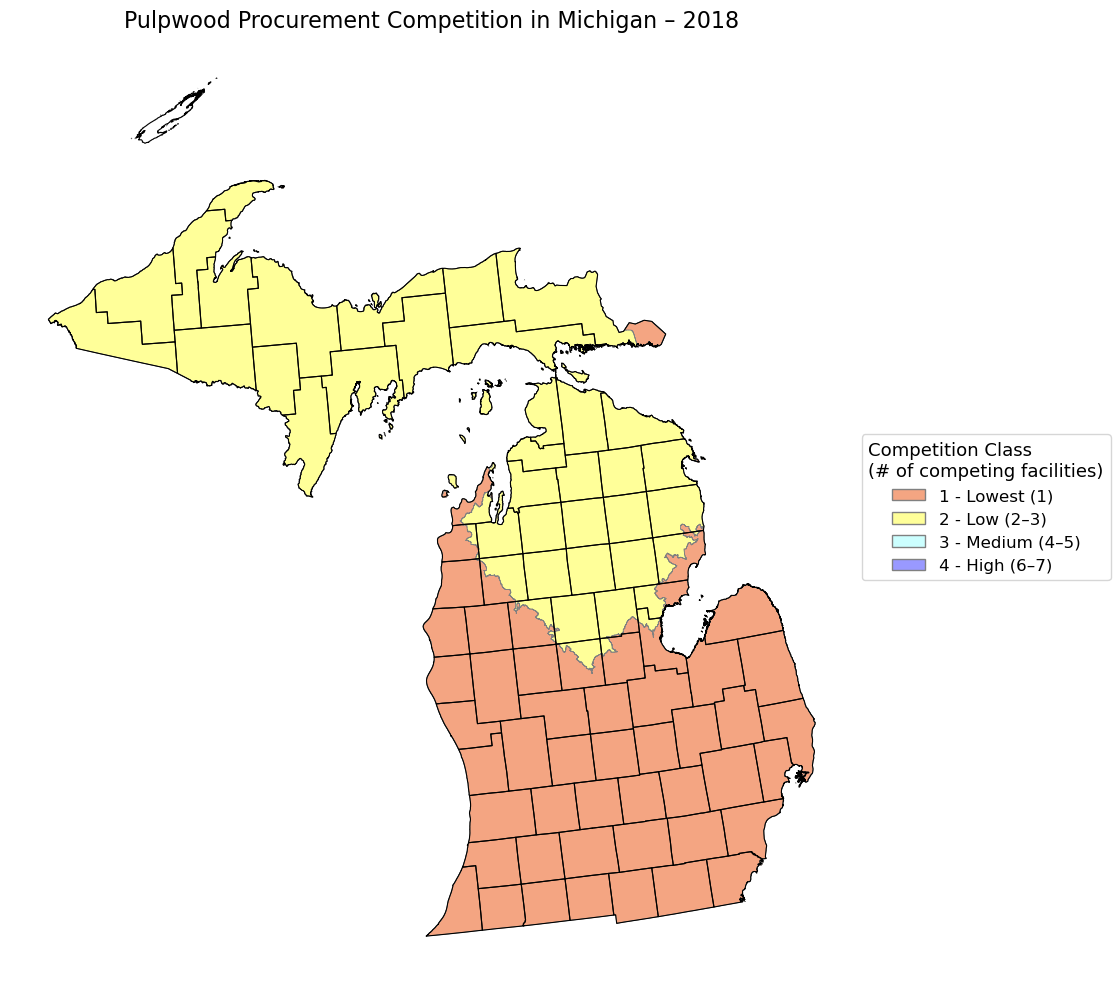

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# File paths
folder = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Khanal Manuscript Sept 2025\Hotspots Final"
michigan_fp = f"{folder}\\Michigan Counties.shp"
hotspot_fp = f"{folder}\\Pulpwood_2018_hotspots.shp"

# Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots = gpd.read_file(hotspot_fp)

# Target CRS: ESRI:102010
target_crs = "ESRI:102010"

# Reproject if needed
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

if gdf_hotspots.crs != target_crs:
    gdf_hotspots = gdf_hotspots.to_crs(target_crs)

# Check 'CompValue' column presence
if 'CompValue' not in gdf_hotspots.columns:
    raise ValueError("The 'CompValue' column is missing in the Pulpwood 2018 hotspots shapefile!")

# Color mapping with updated '#FFFF99' for Low class
color_map = {
    'Lowest': "#F4A582",
    'Low':    "#FFFF99",
    'Medium': "#CCFFFF",
    'High':   "#9999FF"
}

# Map colors to CompValue
gdf_hotspots['color'] = gdf_hotspots['CompValue'].map(color_map)

# Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Michigan counties boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot hotspots
gdf_hotspots.plot(ax=ax, color=gdf_hotspots['color'], edgecolor='grey', linewidth=0.5)

# Legend
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor=color_map['High'], edgecolor='grey', label="4 - High (6–7)")
]

ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and layout
ax.set_title("Pulpwood Procurement Competition in Michigan – 2018", fontsize=16)
ax.set_axis_off()
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


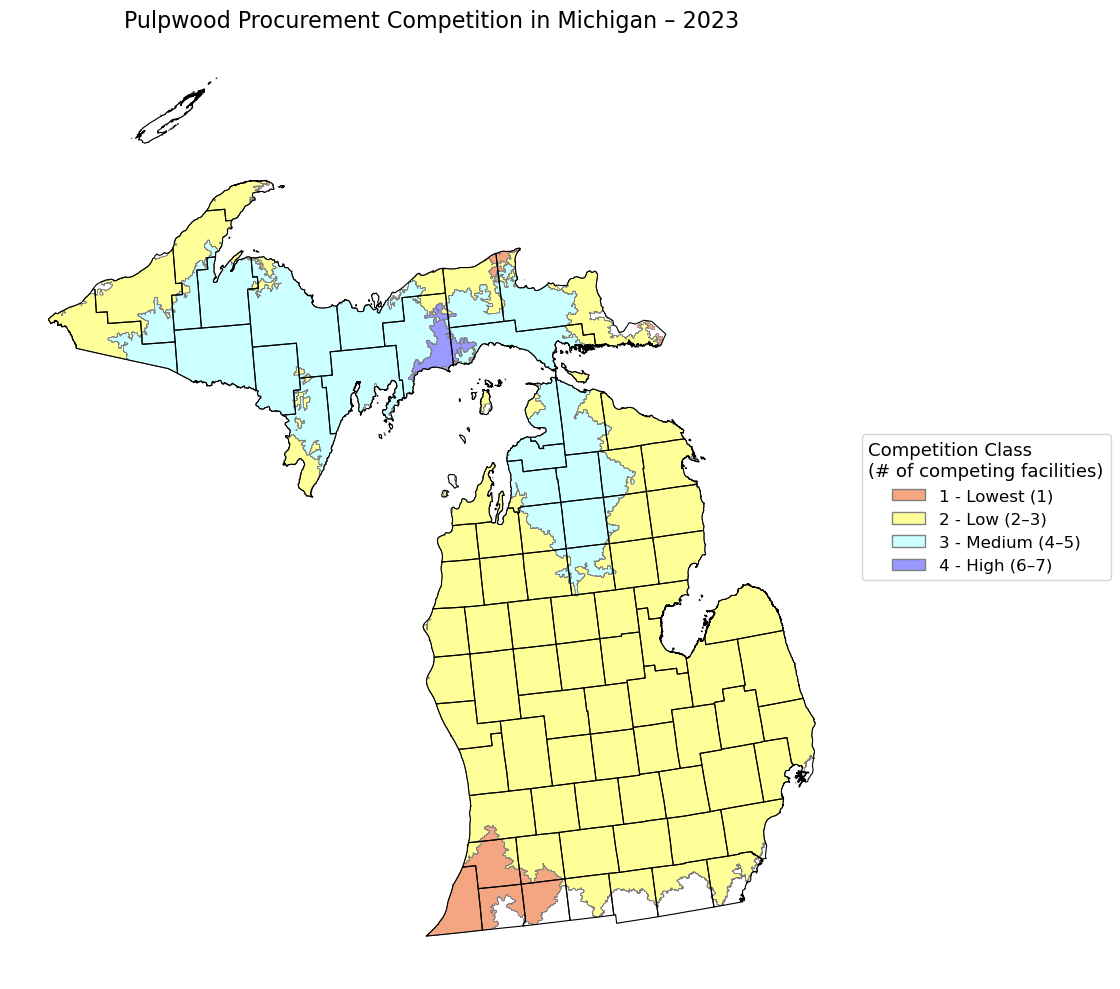

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# File paths
folder = r"C:\Users\khanalna\OneDrive - Oregon State University\Naresh Personal\MSU Manuscript\Khanal Manuscript Sept 2025\Hotspots Final"
michigan_fp = f"{folder}\\Michigan Counties.shp"
hotspot_fp = f"{folder}\\Pulpwood_2023_hotspots.shp"

# Load shapefiles
gdf_michigan = gpd.read_file(michigan_fp)
gdf_hotspots = gpd.read_file(hotspot_fp)

# Target CRS: ESRI:102010
target_crs = "ESRI:102010"

# Reproject if needed
if gdf_michigan.crs != target_crs:
    gdf_michigan = gdf_michigan.to_crs(target_crs)

if gdf_hotspots.crs != target_crs:
    gdf_hotspots = gdf_hotspots.to_crs(target_crs)

# Check 'CompValue' column presence
if 'CompValue' not in gdf_hotspots.columns:
    raise ValueError("The 'CompValue' column is missing in the Pulpwood 2023 hotspots shapefile!")

# Color mapping with updated '#FFFF99' for Low class
color_map = {
    'Lowest': "#F4A582",
    'Low':    "#FFFF99",
    'Medium': "#CCFFFF",
    'High':   "#9999FF"
}

# Map colors to CompValue
gdf_hotspots['color'] = gdf_hotspots['CompValue'].map(color_map)

# Plotting
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Michigan counties boundaries
gdf_michigan.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8)

# Plot hotspots
gdf_hotspots.plot(ax=ax, color=gdf_hotspots['color'], edgecolor='grey', linewidth=0.5)

# Legend
legend_elements = [
    Patch(facecolor=color_map['Lowest'], edgecolor='grey', label="1 - Lowest (1)"),
    Patch(facecolor=color_map['Low'], edgecolor='grey', label="2 - Low (2–3)"),
    Patch(facecolor=color_map['Medium'], edgecolor='grey', label="3 - Medium (4–5)"),
    Patch(facecolor=color_map['High'], edgecolor='grey', label="4 - High (6–7)")
]

ax.legend(
    handles=legend_elements,
    title="Competition Class\n(# of competing facilities)",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

# Title and layout
ax.set_title("Pulpwood Procurement Competition in Michigan – 2023", fontsize=16)
ax.set_axis_off()
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()
